In [1]:
%matplotlib inline

from pathlib import Path

import numpy
from matplotlib import pyplot
import scipy.signal


# ADU Calibration

This notebook allows detector ADU calibration, by identifying the single electron peak.
Knowing the ADU allows accurately modeling the detector noise statistics.

## Data loading

Here we load a dataset. Any dataset may work, but the ideal is a vacuum scan taken at low beam current and large camera length, to spread the beam completely over the detector. Alternatively, single electron events are usually visible in the dark field of datasets taken over a sample at lower camera length.

The below code loads an EMPAD dataset; the data loading may be adapted for your specific detector.

(8100, 128, 128)
(8100, 124, 124)


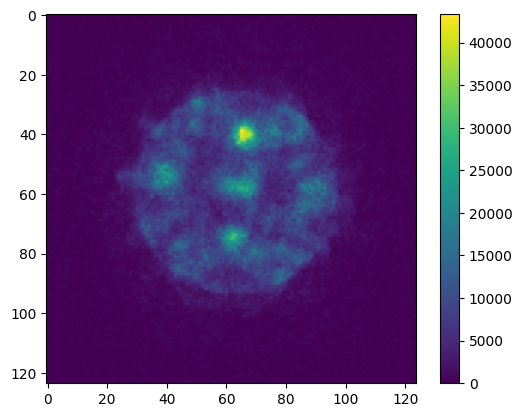

In [2]:
from phaser.io.empad import load_4d
path = Path("../sample_data/experimental_si/scan_x90_y90.raw")

raw = load_4d(path).reshape(-1, 128, 128)
print(raw.shape)

# crop edge pixels of EMPAD; they're larger than the central pixels
cropped = raw[..., 2:128-2, 2:128-2]
print(cropped.shape)

# grab one frame for preview
frame = cropped[500]

fig, ax = pyplot.subplots()
fig.colorbar(ax.imshow(frame))
pyplot.show()

## Event identification

Here, we identify and integrate single electron events.

Two parameters are important:
- `bg` is the threshold used to separate events. This should be close to the noise floor of the detector, for the EMPAD `20.0` is a good starting value
- `max_size` is the maximum number of pixels per event. Bright regions larger than this likely contain multiple events and are discarded. `10` is a good starting value

Three images are plotted. From left to right:
- Raw frame
- Binarized frame, yellow region contains signal above `bg`
- Filtered events, after discarding regions bigger than `max_size`

If you can't find a good combination of parameters, it's likely your dataset dose is too high.

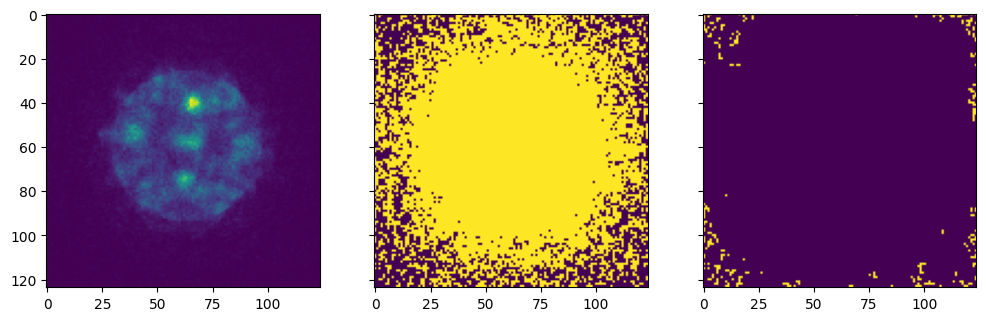

In [8]:
# requires scikit-image (`pip install scikit-image`)

import skimage.measure

def segment_peaks(frame: numpy.ndarray, bg: float = 100.0, max_size: int = 5):
    mask = frame > bg

    (labels, n_labels) = skimage.measure.label(mask, return_num=True)  # type: ignore

    filtered_labels = labels.copy()
    counts = []

    for label in range(n_labels):
        members = labels == label
        if numpy.sum(members) > max_size:
            filtered_labels[members] = 0
            continue
        counts.append(numpy.sum(frame[members]))

    return {
        'counts': numpy.array(counts),
        'mask': mask,
        'labels': filtered_labels,
    }

result = segment_peaks(frame, bg=50.0, max_size=10)

fig, (ax1, ax2, ax3) = pyplot.subplots(ncols=3, sharex=True, sharey=True)
fig.set_size_inches(12, 6)

ax1.imshow(frame)
ax2.imshow(result['mask'])
ax3.imshow(result['labels'] > 0)
pyplot.show()

Next, we process the entire dataset. `n_frames` can be decreased to process only a subset of the data.

In [4]:
from concurrent.futures import ThreadPoolExecutor

executor = ThreadPoolExecutor()

n_frames = 4096  # can decrease this to run a subset of frames
frames = numpy.split(cropped[:n_frames], min(n_frames, cropped.shape[0]), 0)
all_counts = numpy.concatenate(list(executor.map(lambda frame: segment_peaks(frame[0])['counts'], frames)))

Finally, we plot the histogram. Done correctly, you should see strong peaks at multiples of the ADU.
Ensure the correct peak is identified.

Detected ADU: 380.1513671875


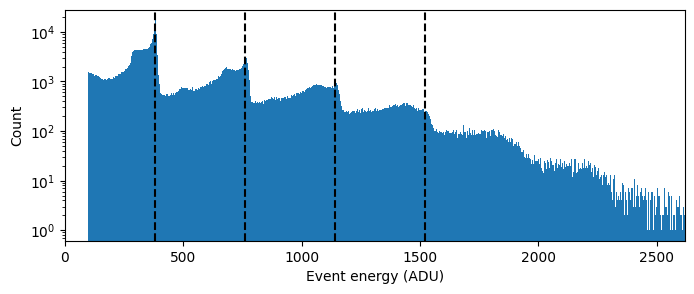

In [5]:
(hist, edges) = numpy.histogram(all_counts, bins=1000)
widths = numpy.diff(edges)

peaks, properties = scipy.signal.find_peaks(hist, distance=20, prominence=0.01 * numpy.max(hist))
adu = float(edges[peaks[0]]) if len(peaks) else None

fig, ax = pyplot.subplots()
fig.set_size_inches(8, 3)
ax.set_xlabel("Event energy (ADU)")
ax.set_yscale('log')
ax.set_ylabel("Count")
ax.set_xlim(0., 0.7 * numpy.max(edges))

if adu:
    print(f"Detected ADU: {adu}")
    for mult in range(1, 4+1):
        ax.axvline(mult * adu, color='black', linestyle='--')
else:
    print("No ADU detected. Adjust event extraction or peak fitting, or try a different dataset.")

ax.bar(edges[:-1], hist, width=widths, align='edge')

pyplot.show()

Using the ADU, you can also calculate the beam current. This provides a good cross check of the calibration.

In [6]:
int_per_frame = numpy.sum(raw) / numpy.prod(raw.shape[:-2])  # ADU / frame
e_per_frame = int_per_frame / adu  # e- / frame
curr = e_per_frame * 1.60217663e-19 / 1e-3  # e- / frame * q [C] / e- / (t [s] / frame) = current/time [A]

scan_step = 0.35 # angstrom

print(f"beam current: {curr*1e12} pA")
print(f"pattern dose: {e_per_frame:.3e} e-")
print(f"dose: {e_per_frame / scan_step**2:.3e} e-/A^2 (assuming scan_step = {scan_step} A)")

beam current: 17.05489385423176 pA
pattern dose: 1.064e+05 e-
dose: 8.690e+05 e-/A^2 (assuming scan_step = 0.35 A)
